<a href="https://colab.research.google.com/github/VysockovEgor/Lessons-of-the-Present-2025/blob/master/%D0%A3%D1%80%D0%BE%D0%BA%D0%B8_%D0%9D%D0%B0%D1%81%D1%82%D0%BE%D1%8F%D1%89%D0%B5%D0%B3%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Восстановление фото методом резинового листа

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

try:
    from bm3d import bm3d, BM3DProfile
except ImportError:
    bm3d = None
    BM3DProfile = None

# Модель DnCNN без BatchNorm, рассчитанная на один канал
class DnCNN(nn.Module):
    def __init__(self, channels=1, num_of_layers=17):
        super(DnCNN, self).__init__()
        layers = [nn.Conv2d(channels, 64, kernel_size=3, padding=1, bias=True), nn.ReLU(inplace=True)]
        for _ in range(num_of_layers - 2):
            layers.append(nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=True))
            layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Conv2d(64, channels, kernel_size=3, padding=1, bias=True))
        self.dncnn = nn.Sequential(*layers)
    def forward(self, x):
        return x - self.dncnn(x)

def denoise_image_color_cv2(img):
    return cv2.fastNlMeansDenoisingColored(img, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21)

def denoise_image_color_bm3d(img):
    if bm3d is None or BM3DProfile is None:
        return denoise_image_color_cv2(img)
    img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    y, cr, cb = cv2.split(img_ycrcb)
    y_float = y.astype(np.float32) / 255.0
    y_denoised = bm3d(y_float, sigma_psd=0.1, profile=BM3DProfile())
    y_denoised_uint8 = np.clip(y_denoised * 255, 0, 255).astype(np.uint8)
    denoised_ycrcb = cv2.merge((y_denoised_uint8, cr, cb))
    return cv2.cvtColor(denoised_ycrcb, cv2.COLOR_YCrCb2BGR)

def denoise_image_color_dncnn(img):
    # Преобразуем входное цветное изображение в оттенки серого,
    # так как предобученные веса рассчитаны на один канал.
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Приводим изображение к формату, подходящему для PyTorch (N, C, H, W)
    img_float = img_gray.astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img_float).unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    img_tensor = img_tensor.to(device)
    # Создаём модель с одним входным каналом и без BatchNorm
    model = DnCNN(channels=1, num_of_layers=17).to(device)
    # Загрузка состояния: ключи в файле должны иметь префикс "model." – заменяем на "dncnn."
    state_dict = torch.load("/dncnn_15.pth", map_location=device)
    new_state_dict = {key.replace("model.", "dncnn."): value for key, value in state_dict.items()}
    model.load_state_dict(new_state_dict)
    model.eval()
    with torch.no_grad():
        denoised_tensor = model(img_tensor)
    # Результат – остаток (шум), поэтому чистое изображение:
    clean_tensor = img_tensor - denoised_tensor
    clean_np = clean_tensor.squeeze().cpu().numpy()
    clean_np = np.clip(clean_np * 255, 0, 255).astype(np.uint8)
    # Для отображения возвращаем изображение в формате BGR, повторив канал по трём осям
    clean_bgr = cv2.cvtColor(clean_np, cv2.COLOR_GRAY2BGR)
    return clean_bgr

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise IOError(f"Не удалось открыть изображение по пути: {path}")
    return img

def preprocess_image_color(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)

def sharpen_image_color(img):
    gaussian = cv2.GaussianBlur(img, (9, 9), sigmaX=10.0)
    return cv2.addWeighted(img, 1.5, gaussian, -0.5, 0)

# Функция, реализующая восстановление фото методом резинового листа
def rubber_sheet_restoration(img, k=0.000001):
    """
    Параметры:
        img - исходное изображение
        k   - коэффициент деформации (подбирайте опытно: k>0 – сжатие, k<0 – растяжение)
    Метод вычисляет новую карту координат с нелинейным обратным отображением и использует cv2.remap.
    """
    h, w = img.shape[:2]
    cx, cy = w / 2, h / 2
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    # Вычисляем квадрат расстояния от центра
    r_squared = (x - cx) ** 2 + (y - cy) ** 2
    # Обратное нелинейное отображение: корректировка координат
    map_x = ((x - cx) / (1 + k * r_squared)) + cx
    map_y = ((y - cy) / (1 + k * r_squared)) + cy
    restored_img = cv2.remap(img, map_x.astype(np.float32), map_y.astype(np.float32), interpolation=cv2.INTER_LINEAR)
    return restored_img

def process_satellite_image_color(path, method="dncnn"):
    img = load_image(path)
    preprocessed = preprocess_image_color(img)
    sharpened = sharpen_image_color(preprocessed)
    if method == "cv2":
        processed = denoise_image_color_cv2(sharpened)
    elif method == "bm3d":
        processed = denoise_image_color_bm3d(sharpened)
    elif method == "dncnn":
        processed = denoise_image_color_dncnn(sharpened)
    elif method == "rubber":
        # Восстановление методом резинового листа: подберите параметр k при необходимости
        processed = rubber_sheet_restoration(sharpened, k=0.000001)
    else:
        processed = denoise_image_color_cv2(sharpened)
    return {"original": img, "preprocessed": preprocessed, "sharpened": sharpened, "processed": processed}

def display_results(results, titles=None):
    if titles is None:
        titles = ["Оригинал", "Предобработка", "Повышение резкости", "Восстановление"]
    images = [results["original"], results["preprocessed"], results["sharpened"], results["processed"]]
    plt.figure(figsize=(15, 8))
    for i in range(len(images)):
        plt.subplot(2, 2, i + 1)
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    image_path = "Temp.bmp"
    # Выбираем метод "rubber" для восстановления через резиновый лист
    results = process_satellite_image_color(image_path, method="rubber")
    display_results(results)


OSError: Не удалось открыть изображение по пути: Temp.bmp

# Восстановление фотографии медианным фильтром

В этом ноутбуке выполняется портирование исходного кода. Фотография повреждается удалением заданного процента строк, затем восстанавливается с помощью медианного фильтра. В конце вычисляются метрики восстановления (MSE и PSNR) для оценки качества восстановления.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import random
from copy import deepcopy
import math

In [ ]:
# Задаём параметры
damage = 20         # Процент удаляемых строк
filter_size = 5     # Размер медианного фильтра

In [ ]:
# Функция медианного фильтра
def median_filter_2d(image, kernel_size, deleted_rows):
    arr = np.array(deepcopy(image))
    padded_arr = np.pad(arr, kernel_size // 2, mode='edge')
    filtered_arr = np.zeros_like(arr)

    for i in range(arr.shape[0]):
        if i in deleted_rows:
            for j in range(arr.shape[1]):
                window = padded_arr[i:i+kernel_size, j:j+kernel_size]
                filtered_arr[i, j] = np.median(window)
        else:
            filtered_arr[i] = arr[i]

    return filtered_arr

# Функция для удаления заданного процента строк
def delete_some_rows(percentage, image):
    image_mod = deepcopy(image)
    deleted_rows = []
    rows = list(range(len(image)))
    target = int(len(image) * percentage)
    while len(deleted_rows) < target:
        line_id = random.randint(0, len(image) - len(deleted_rows) - 1)
        line = rows[line_id]
        rows[line_id] = rows[len(image) - len(deleted_rows) - 1]
        if line in deleted_rows:
            continue
        deleted_rows.append(line)
        for i in range(len(image[0])):
            image_mod[line][i] = -100  # Отметка удалённой строки
    return image_mod, deleted_rows

In [ ]:
# Чтение фотографии из файла
# Файл "65-161day-04dec2023.txt" должен находиться в той же папке
with open("65-161day-04dec2023.txt", "r") as f:
    service_info = f.readline()
    width_mkm, _, height_mkm, _, heights, _, width_x, height_y = service_info.split()
    width_mkm = float(width_mkm)
    height_mkm = float(height_mkm)
    heights = float(heights)
    width_x = int(width_x)
    height_y = int(height_y)

    image = []
    for line in f:
        my_line = list(map(float, line.split()))
        image.append(my_line)

In [ ]:
# Порча фотографии
image_corrupt, deleted_rows = delete_some_rows(damage / 100, image)

# Восстановление фотографии
image_restored = median_filter_2d(image_corrupt, filter_size, deleted_rows)

# MSE и PSNR

## MSE (Mean Squared Error, среднеквадратичная ошибка)

**Определение:**  
MSE вычисляет среднее значение квадратов разности между значениями пикселей оригинального изображения и восстановленного (или обработанного) изображения. Формула выглядит следующим образом:

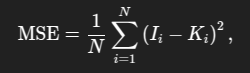

где:
- \( I_i \) — значение i-го пикселя оригинального изображения,
- \( K_i \) — значение i-го пикселя восстановленного изображения,
- \( N \) — общее количество пикселей.

**Интерпретация:**  
- **Низкое значение MSE:** означает, что восстановленное изображение близко к оригиналу.
- **Высокое значение MSE:** указывает на значительные отклонения между оригиналом и обработанным изображением.

---

## PSNR (Peak Signal-to-Noise Ratio, пиковое отношение сигнал/шум)

**Определение:**  
PSNR измеряет отношение максимального возможного значения сигнала к уровню шума, возникающему из-за ошибок (вычисляемых по MSE). Эта метрика выражается в децибелах (dB). Формула PSNR:

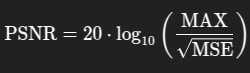

где:
- **MAX** — максимальное значение интенсивности пикселя ,
- **MSE** — среднеквадратичная ошибка, рассчитанная по предыдущей формуле.

**Интерпретация:**  
- **Высокий PSNR:** свидетельствует о том, что уровень шума невысок, что означает лучшее качество восстановления изображения. Обычно значение PSNR выше 30 дБ считается приемлемым для сжатых изображений.
- **Низкий PSNR:** указывает на более высокую степень ошибок и, соответственно, значительный шум.

---

## Сравнение и применение

- **MSE** предоставляет количественную меру разницы между изображениями, позволяя непосредственно оценить абсолютное отклонение каждого пикселя.
- **PSNR** переводит эту ошибку в логарифмическую шкалу (децибелы), что способствует лучшему пониманию визуального качества восстановления.

Обе метрики часто используются вместе, чтобы обеспечить более полную оценку качества в задачах обработки, сжатия и восстановления изображений.


In [ ]:
original_arr = np.array(image)
restored_arr = np.array(image_restored)
max_val = 100  # или подберите подходящее значение

row_indices = []
mse_per_row = []
psnr_per_row = []

for i in sorted(deleted_rows):
    row_indices.append(i)
    mse_row = np.mean((original_arr[i, :] - restored_arr[i, :])**2)
    mse_per_row.append(mse_row)
    if mse_row == 0:
        psnr_row = float('inf')
    else:
        psnr_row = 20 * math.log10(max_val / math.sqrt(mse_row))
    psnr_per_row.append(psnr_row)


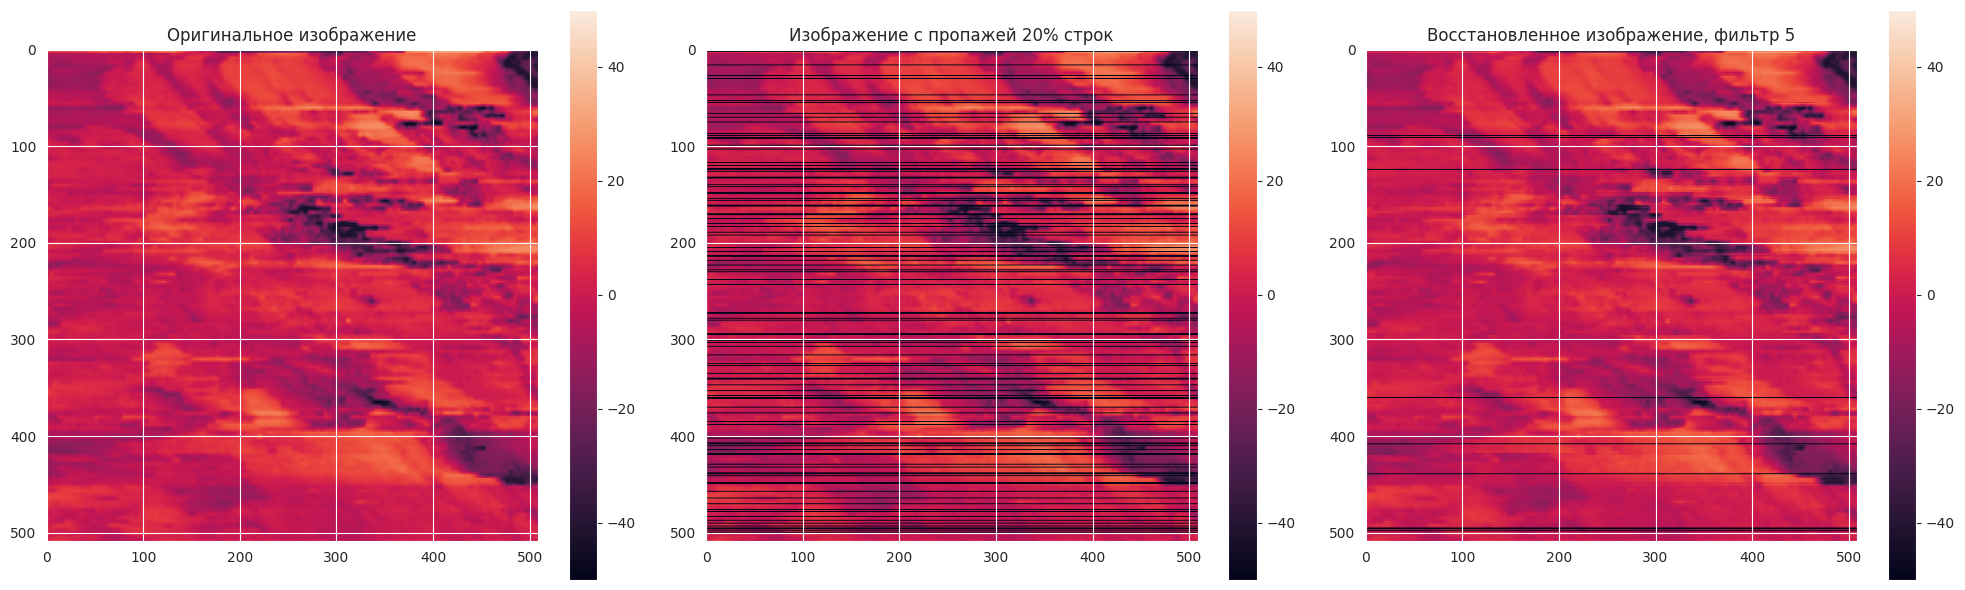

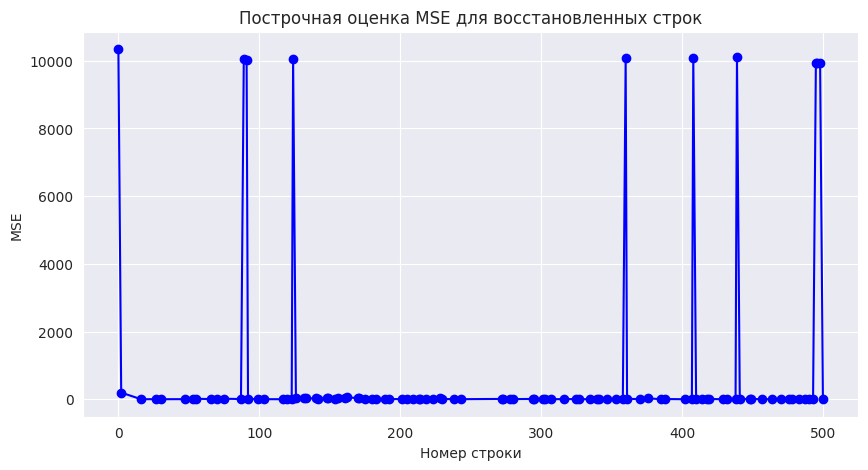

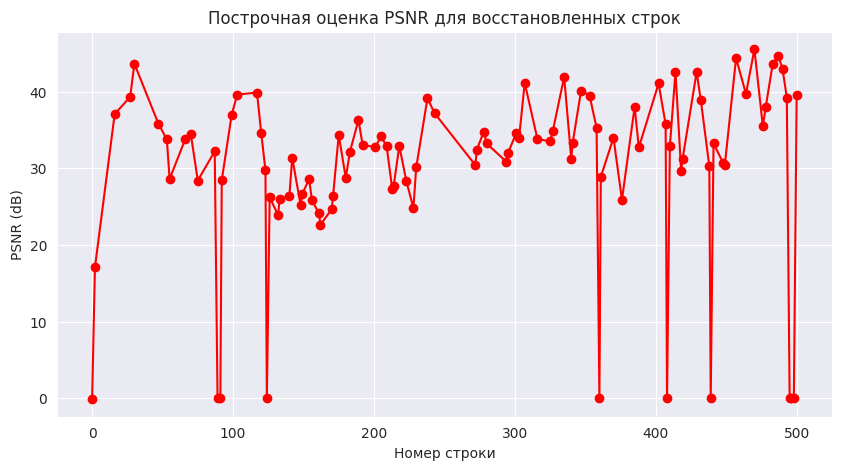

In [ ]:
# Визуализация результатов
fig1, ax1 = plt.subplots(1, 3, figsize=(20, 6))
a1 = ax1[0].imshow(original_arr, vmin=-50, vmax=50)
ax1[0].set_title("Оригинальное изображение")
fig1.colorbar(a1, ax=ax1[0])

a2 = ax1[1].imshow(np.array(image_corrupt), vmin=-50, vmax=50)
ax1[1].set_title(f"Изображение с пропажей {damage}% строк")
fig1.colorbar(a2, ax=ax1[1])

a3 = ax1[2].imshow(restored_arr, vmin=-50, vmax=50)
ax1[2].set_title(f"Восстановленное изображение, фильтр {filter_size}")
fig1.colorbar(a3, ax=ax1[2])
plt.tight_layout()
plt.show()

# 2. Визуализация метрик для восстановленных строк

# График MSE по строкам
plt.figure(figsize=(10,5))
plt.plot(row_indices, mse_per_row, 'b-o')
plt.xlabel("Номер строки")
plt.ylabel("MSE")
plt.title("Построчная оценка MSE для восстановленных строк")
plt.grid(True)
plt.show()

# График PSNR по строкам
plt.figure(figsize=(10,5))
plt.plot(row_indices, psnr_per_row, 'r-o')
plt.xlabel("Номер строки")
plt.ylabel("PSNR (dB)")
plt.title("Построчная оценка PSNR для восстановленных строк")
plt.grid(True)
plt.show()

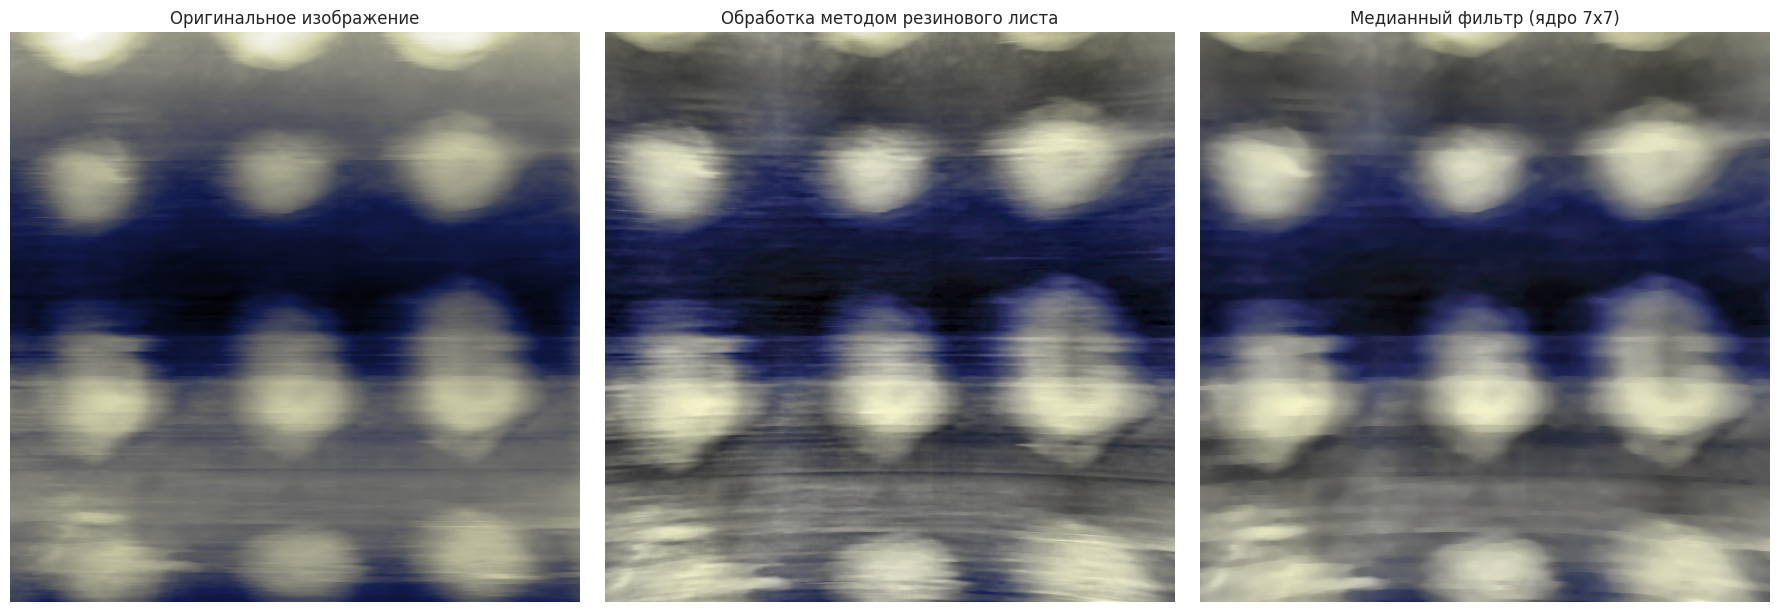

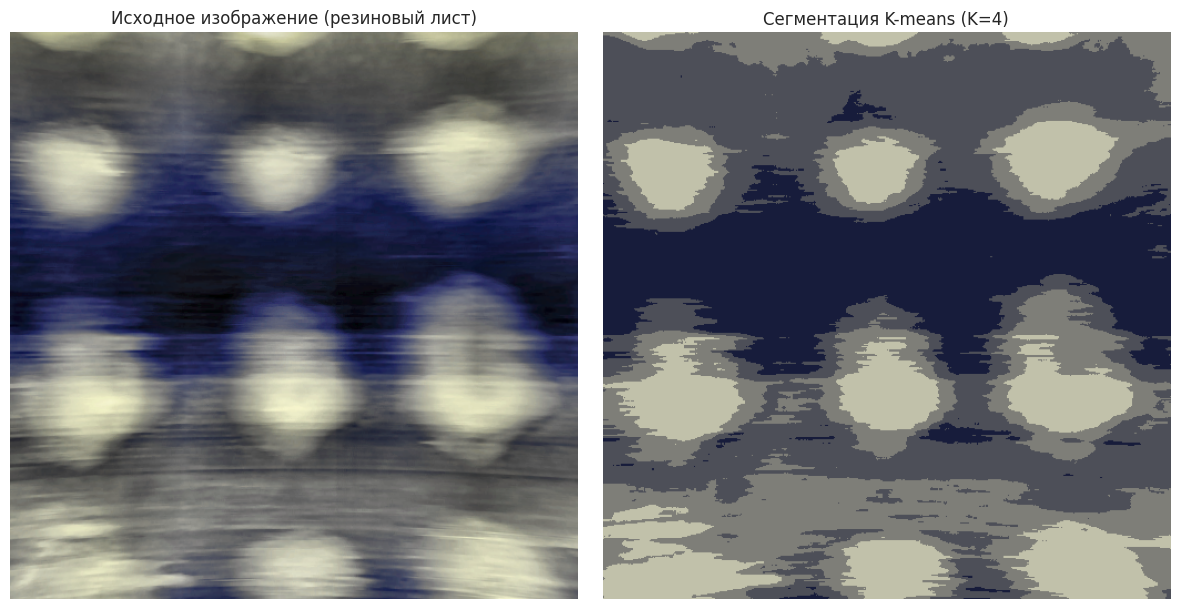

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- Применение медианного фильтра, как в вашем примере ---
median_filter_size = 7
median_filtered_img = cv2.medianBlur(results["processed"], median_filter_size)

# Отображение исходного, обработанного и медианно-фильтрованного изображений
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(results["original"], cv2.COLOR_BGR2RGB))
plt.title("Оригинальное изображение")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(results["processed"], cv2.COLOR_BGR2RGB))
plt.title("Обработка методом резинового листа")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(median_filtered_img, cv2.COLOR_BGR2RGB))
plt.title(f"Медианный фильтр (ядро {median_filter_size}x{median_filter_size})")
plt.axis("off")

plt.tight_layout()
plt.show()

# --- Сегментация изображения с использованием K‑means ---
# Выберем изображение для сегментации. В данном примере – результат обработки методом резинового листа.
img = results["processed"]

# Преобразуем изображение в формат [N, 3] для алгоритма кластеризации
Z = img.reshape((-1, 3))
Z = np.float32(Z)

# Определяем критерии завершения алгоритма K-means: либо 10 итераций, либо изменение меньше 1.0
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 4  # число кластеров (сегментов), можно изменять по необходимости
ret, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Преобразуем центроиды обратно в uint8 и формируем сегментированное изображение
center = np.uint8(center)
segmented_data = center[label.flatten()]
segmented_img = segmented_data.reshape((img.shape))

# --- Визуализация результатов сегментации ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Исходное изображение (резиновый лист)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB))
plt.title(f"Сегментация K-means (K={K})")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
%matplotlib notebook
import numpy as np
from matplotlib import pyplot as plt

# Чтение файла с данными
with open("./Norm.txt") as f:
    servise_info = f.readline()
    width_mkm, _, height_mkm, _, heights, _, width_x, height_y = servise_info.split()
    width_mkm = float(width_mkm)
    height_mkm = float(height_mkm)
    heights = float(heights)
    width_x = float(width_x)
    height_y = float(height_y)

    image = []
    for line in f:
        my_line = list(map(float, line.split()))
        image.append(my_line)

image = np.array(image)

# Определяем координаты для построения поверхности
rows, cols = image.shape
x = np.linspace(0, width_x, cols)
y = np.linspace(0, height_y, rows)
X, Y = np.meshgrid(x, y)

# Создаём 3D-график
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.plot_surface(X, Y, image, cmap='viridis')

plt.show()


<IPython.core.display.Javascript object>

In [ ]:
import json
import numpy as np


with open("data.json", "r") as f:
    js = json.load(f)
    data = js["data"]
    sun_flares = js["sun_flares"]

USb1 = []
USb2 = []
USb3 = []
mb = []
for d in data:
    USb1.append(d[1])
    USb2.append(d[2])
    USb3.append(d[3])

for i, n in enumerate(sun_flares):
    mb.append(float(n["long"]))
    if len(mb) == len(USb1):
        break

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.DataFrame({
    "Напряжение СБ №1": USb1,
    "Напряжение СБ №2": USb2,
    "Напряжение СБ №3": USb3,
    "Солнечные вспышки": mb
})

# Вычисляем матрицу корреляций
corr_matrix = df.corr()
print("Матрица корреляции:")
print(corr_matrix)

# 1. Тепловая карта корреляционной матрицы
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Тепловая карта корреляции")
plt.show()

# 2. Pairplot (scatter plot matrix) для визуализации зависимостей между переменными
sns.pairplot(df)
plt.suptitle("Матрица диаграмм рассеяния", y=1.02)
plt.show()


Матрица корреляции:
                   Напряжение СБ №1  Напряжение СБ №2  Напряжение СБ №3  \
Напряжение СБ №1           1.000000          0.887599          0.852453   
Напряжение СБ №2           0.887599          1.000000          0.846845   
Напряжение СБ №3           0.852453          0.846845          1.000000   
Солнечные вспышки          0.034457          0.059678          0.049741   

                   Солнечные вспышки  
Напряжение СБ №1            0.034457  
Напряжение СБ №2            0.059678  
Напряжение СБ №3            0.049741  
Солнечные вспышки           1.000000  


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>